# Download Dataset From Kaggle

- https://www.kaggle.com/datasets/carrie1/ecommerce-data

In [21]:
#!/bin/bash
!kaggle datasets download carrie1/ecommerce-data

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
ecommerce-data.zip: Skipping, found more recently modified local copy (use --force to force download)


In [22]:
import zipfile

# Specify the path to your zip file
zip_path = "/content/ecommerce-data.zip"

# Unzip everything to the current directory
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/eCommerce.csv")

# Step 1: Creating a SparkSession

In [23]:
import warnings
warnings.filterwarnings('ignore')
from pyspark.sql import SparkSession

In [24]:
spark = SparkSession.builder.appName("Pyspark Tutorial").getOrCreate()

# Step 2: Creating the DataFrame

In [25]:
df = spark.read.csv('eCommerce.csv',header=True,escape="\"")

In [26]:

df.show(5,0)

+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate   |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |12/1/2010 8:26|2.55     |17850     |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6       |12/1/2010 8:26|3.39     |17850     |United Kingdom|
|536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |12/1/2010 8:26|2.75     |17850     |United Kingdom|
|536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |12/1/2010 8:26|3.39     |17850     |United Kingdom|
|536365   |84029E   |RED WOOLLY HOTTIE WHITE HEART.     |6       |12/1/2010 8:26|3.39     |17850     |United Kingdom|
+---------+---------+-----------------------------------

The dataframe consists of 8 variables:

- InvoiceNo: The unique identifier of each customer invoice.
- StockCode: The unique identifier of each item in stock.
- Description: The item purchased by the customer.
- Quantity: The number of each item purchased by a customer in a single invoice.
- InvoiceDate: The purchase date.
- UnitPrice: Price of one unit of each item.
- CustomerID: Unique identifier assigned to each user.
- Country: The country from where the purchase was made

# Step 3: Exploratory Data Analysis

Now that we have seen the variables present in this dataset, let’s perform some exploratory data analysis to further understand these data points:

Let’s start by counting the number of rows in the dataframe:

In [27]:
df.count()

541909

## How many unique customers are present in the dataframe?

In [28]:
df.select('CustomerID').distinct().count()

4373

## What country do most purchases come from?

To find the country from which most purchases are made, we need to use the groupBy() clause in PySpark

In [29]:
import pyspark.sql.functions as F
from pyspark.sql.types import *

df.groupBy('Country').agg(F.countDistinct('CustomerID').alias('country_count')).show()

+------------------+-------------+
|           Country|country_count|
+------------------+-------------+
|            Sweden|            8|
|         Singapore|            1|
|           Germany|           95|
|               RSA|            1|
|            France|           87|
|            Greece|            4|
|European Community|            1|
|           Belgium|           25|
|           Finland|           12|
|             Malta|            2|
|       Unspecified|            4|
|             Italy|           15|
|              EIRE|            3|
|         Lithuania|            1|
|            Norway|           10|
|             Spain|           31|
|           Denmark|            9|
|         Hong Kong|            0|
|            Israel|            4|
|           Iceland|            1|
+------------------+-------------+
only showing top 20 rows


Almost all the purchases on the platform were made from the United Kingdom, and only a handful were made from countries like Germany, Australia, and France.

Notice that the data in the table above isn’t presented in the order of purchases. To sort this table, we can include the orderBy() clause

In [30]:
df.groupBy('Country').agg(F.countDistinct('CustomerID').alias('country_count')).orderBy(F.desc('country_count')).show()

+---------------+-------------+
|        Country|country_count|
+---------------+-------------+
| United Kingdom|         3950|
|        Germany|           95|
|         France|           87|
|          Spain|           31|
|        Belgium|           25|
|    Switzerland|           21|
|       Portugal|           19|
|          Italy|           15|
|        Finland|           12|
|        Austria|           11|
|         Norway|           10|
|        Denmark|            9|
|Channel Islands|            9|
|      Australia|            9|
|    Netherlands|            9|
|         Sweden|            8|
|         Cyprus|            8|
|          Japan|            8|
|         Poland|            6|
|         Greece|            4|
+---------------+-------------+
only showing top 20 rows


## When was the most recent purchase made by a customer on the e-commerce platform?
To find when the latest purchase was made on the platform, we need to convert the “InvoiceDate” column into a timestamp format and use the max() function in Pyspark:

In [32]:

spark.sql("set spark.sql.legacy.timeParserPolicy=LEGACY")
df = df.withColumn('date',to_timestamp("InvoiceDate", 'MM/dd/yyyy HH:mm'))
df.select(max("date")).show()

+-------------------+
|          max(date)|
+-------------------+
|2011-12-09 12:50:00|
+-------------------+



## When was the earliest purchase made by a customer on the e-commerce platform?
Similar to what we did above, the min() function can be used to find the earliest purchase date and time

In [33]:

df.select(min("date")).show()

+-------------------+
|          min(date)|
+-------------------+
|2010-12-01 08:26:00|
+-------------------+



Notice that the most recent and earliest purchases were made on the same day just a few hours apart. This means that the dataset we downloaded contains information of only purchases made on a single day.

# Step 4: Data Pre-processing

Now that we have analyzed the dataset and have a better understanding of each data point, we need to prepare the data to feed into the machine learning algorithm.

Let’s take a look at the head of the dataframe once again to understand how the pre-processing will be done

In [34]:
df.show(5,0)

+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+-------------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate   |UnitPrice|CustomerID|Country       |date               |
+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+-------------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |12/1/2010 8:26|2.55     |17850     |United Kingdom|2010-12-01 08:26:00|
|536365   |71053    |WHITE METAL LANTERN                |6       |12/1/2010 8:26|3.39     |17850     |United Kingdom|2010-12-01 08:26:00|
|536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |12/1/2010 8:26|2.75     |17850     |United Kingdom|2010-12-01 08:26:00|
|536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |12/1/2010 8:26|3.39     |17850     |United Kingdom|2010-12-01 08:26:00|
|536365   |84029E   |RED WOOLLY HO

**Recency**

First, let’s calculate the value of recency - the latest date and time a purchase was made on the platform. This can be achieved in two steps:

i) Assign a recency score to each customer
We will subtract every date in the dataframe from the earliest date. This will tell us how recently a customer was seen in the dataframe. A value of 0 indicates the lowest recency, as it will be assigned to the person who was seen making a purchase on the earliest date.

In [35]:

df = df.withColumn("from_date", lit("12/1/10 08:26"))
df = df.withColumn('from_date',to_timestamp("from_date", 'yy/MM/dd HH:mm'))

df2 = df.withColumn('recency',col("date").cast("long") - col('from_date').cast("long"))

In [36]:
df2.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+-------------------+-------------------+---------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|               date|          from_date|  recency|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+-------------------+-------------------+---------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|2010-12-01 08:26:00|2012-01-10 08:26:00|-34992000|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|2010-12-01 08:26:00|2012-01-10 08:26:00|-34992000|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|2010-12-01 08:26:00|2012-01-10 08:26:00|-34992000|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     1

ii) Select the most recent purchase

One customer can make multiple purchases at different times. We need to select only the last time they were seen buying a product, as this is indicative of when the most recent purchase was made:

In [37]:

df2 = df2.join(df2.groupBy('CustomerID').agg(max('recency').alias('recency')),on='recency',how='leftsemi')

Let’s look at the head of the new dataframe. It now has a variable called “recency” appended to it:

In [38]:
df2.show(5,0)

+---------+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+-------------------+-------------------+
|recency  |InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate   |UnitPrice|CustomerID|Country       |date               |from_date          |
+---------+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+-------------------+-------------------+
|-34986780|536384   |82484    |WOOD BLACK BOARD ANT WHITE FINISH  |3       |12/1/2010 9:53|6.45     |18074     |United Kingdom|2010-12-01 09:53:00|2012-01-10 08:26:00|
|-34986780|536384   |84755    |COLOUR GLASS T-LIGHT HOLDER HANGING|48      |12/1/2010 9:53|0.65     |18074     |United Kingdom|2010-12-01 09:53:00|2012-01-10 08:26:00|
|-34986780|536384   |22464    |HANGING METAL HEART LANTERN        |12      |12/1/2010 9:53|1.65     |18074     |United Kingdom|2010-12-01 09:53:00|2012-01-10 08

An easier way to view all the variables present in a PySpark dataframe is to use its printSchema() function. This is the equivalent of the info() function in Pandas:

In [39]:

df2.printSchema()

root
 |-- recency: long (nullable = true)
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: string (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- from_date: timestamp (nullable = false)



**Frequency**

Let’s now calculate the value of frequency - how often a customer bought something on the platform. To do this, we just need to group by each customer ID and count the number of items they purchased:




In [40]:

df_freq = df2.groupBy('CustomerID').agg(count('InvoiceDate').alias('frequency'))

In [41]:
df_freq.show(5,0)

+----------+---------+
|CustomerID|frequency|
+----------+---------+
|17714     |10       |
|16250     |10       |
|15574     |9        |
|16320     |9        |
|17551     |43       |
+----------+---------+
only showing top 5 rows


There is a frequency value appended to each customer in the dataframe. This new dataframe only has two columns, and we need to join it with the previous one:

In [42]:

df3 = df2.join(df_freq,on='CustomerID',how='inner')

In [43]:
df3.printSchema()

root
 |-- CustomerID: string (nullable = true)
 |-- recency: long (nullable = true)
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- from_date: timestamp (nullable = false)
 |-- frequency: long (nullable = false)



**Monetary Value**

Finally, let’s calculate monetary value - the total amount spent by each customer in the dataframe. There are two steps to achieving this:

i) Find the total amount spent in each purchase:
Each customerID comes with variables called “Quantity” and “UnitPrice” for a single purchase:



To get the total amount spent by each customer in one purchase, we need to multiply “Quantity” with “UnitPrice”:

In [45]:

m_val = df3.withColumn('TotalAmount',col("Quantity").cast('float') * col("UnitPrice").cast('float'))

ii) Find the total amount spent by each customer:

To find the total amount spent by each customer overall, we just need to group by the CustomerID column and sum the total amount spent:

In [46]:

m_val = m_val.groupBy('CustomerID').agg(sum('TotalAmount').alias('monetary_value'))

Merge this dataframe with the all the other variables:

In [47]:
finaldf = m_val.join(df3,on='CustomerID',how='inner')

Now that we have created all the necessary variables to build the model, run the following lines of code to select only the required columns and drop duplicate rows from the dataframe:

In [48]:
finaldf = finaldf.select(['recency','frequency','monetary_value','CustomerID']).distinct()

In [49]:
finaldf.show(5, 0)

+---------+---------+------------------+----------+
|recency  |frequency|monetary_value    |CustomerID|
+---------+---------+------------------+----------+
|-34195080|46       |272.8200036883354 |16727     |
|-31260840|2        |-6.199999809265137|17406     |
|-30215280|7        |120.9499979019165 |13002     |
|-28402920|10       |1784.7099914550781|14935     |
|-27035520|15       |306.9400100708008 |15087     |
+---------+---------+------------------+----------+
only showing top 5 rows


**Standardization**

Before building the customer segmentation model, let’s standardize the dataframe to ensure that all the variables are around the same scale:

In [50]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler


assemble=VectorAssembler(inputCols=[
    'recency','frequency','monetary_value'
], outputCol='features')

assembled_data=assemble.transform(finaldf)

scale=StandardScaler(inputCol='features',outputCol='standardized')
data_scale=scale.fit(assembled_data)
data_scale_output=data_scale.transform(assembled_data)

Run the following lines of code to see what the standardized feature vector looks like:

In [51]:
data_scale_output.select('standardized').show(2,truncate=False)

+-------------------------------------------------------------+
|standardized                                                 |
+-------------------------------------------------------------+
|[-3.486072822029219,0.25819728443703077,0.05473295544639621] |
|[-2.8997224094312712,0.25819728443703077,0.05841759136107021]|
+-------------------------------------------------------------+
only showing top 2 rows


These are the scaled features that will be fed into the clustering algorithm.

# Step 5: Building the Machine Learning Model

Now that we have completed all the data analysis and preparation, let’s build the K-Means clustering model.

The algorithm will be created using PySpark’s machine learning API.

**i) Finding the number of clusters to use**

When building a K-Means clustering model, we first need to determine the number of clusters or groups we want the algorithm to return. If we decide on three clusters, for instance, then we will have three customer segments.

The most popular technique used to decide on how many clusters to use in K-Means is called the “elbow-method.”

This is done simply running the K-Means algorithm for a wide range of clusters and visualizing the model results for each cluster. The plot will have an inflection point that looks like an elbow, and we just pick the number of clusters at this point.

Let’s run the following lines of code to build a K-Means clustering algorithm from 2 to 10 clusters:

In [52]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import numpy as np



cost = np.zeros(10)

evaluator = ClusteringEvaluator(predictionCol='prediction', featuresCol='standardized',metricName='silhouette', distanceMeasure='squaredEuclidean')

for i in range(2,10):
    KMeans_algo=KMeans(featuresCol='standardized', k=i)
    KMeans_fit=KMeans_algo.fit(data_scale_output)
    output=KMeans_fit.transform(data_scale_output)
    cost[i] = KMeans_fit.summary.trainingCost

With the codes above, we have successfully built and evaluated a K-Means clustering model with 2 to 10 clusters. The results have been placed in an array, and can now be visualized in a line chart.

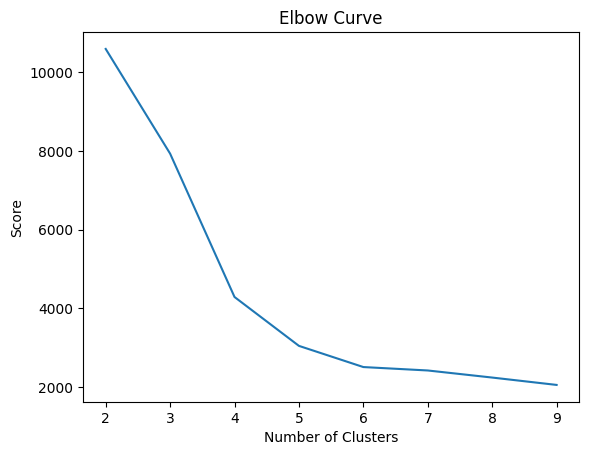

In [53]:
import pandas as pd
import pylab as pl
df_cost = pd.DataFrame(cost[2:])
df_cost.columns = ["cost"]
new_col = range(2,10)
df_cost.insert(0, 'cluster', new_col)
pl.plot(df_cost.cluster, df_cost.cost)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

**ii) Building the K-Means Clustering Model**

From the plot above, we can see that there is an inflection point that looks like an elbow at four. Due to this, we will proceed to build the K-Means algorithm with four clusters:




In [54]:
KMeans_algo=KMeans(featuresCol='standardized', k=4)
KMeans_fit=KMeans_algo.fit(data_scale_output)

**iii) Making Predictions**

Let’s use the model we created to assign clusters to each customer in the dataset:

In [55]:
preds=KMeans_fit.transform(data_scale_output)

preds.show(5,0)

+---------+---------+------------------+----------+------------------------------------+-------------------------------------------------------------+----------+
|recency  |frequency|monetary_value    |CustomerID|features                            |standardized                                                 |prediction|
+---------+---------+------------------+----------+------------------------------------+-------------------------------------------------------------+----------+
|-30405240|10       |153.0             |17714     |[-3.040524E7,10.0,153.0]            |[-3.486072822029219,0.25819728443703077,0.05473295544639621] |1         |
|-25291140|10       |163.2999973297119 |16250     |[-2.529114E7,10.0,163.2999973297119]|[-2.8997224094312712,0.25819728443703077,0.05841759136107021]|1         |
|-18044700|9        |112.0999995470047 |15574     |[-1.80447E7,9.0,112.0999995470047]  |[-2.068891357268374,0.2323775559933277,0.04010172732514538]  |1         |
|-17600460|9        |185.780

# Step 6: Cluster Analysis
The final step in this entire tutorial is to analyze the customer segments we just built.

Run the following lines of code to visualize the recency, frequency, and monetary value of each customerID in the dataframe:

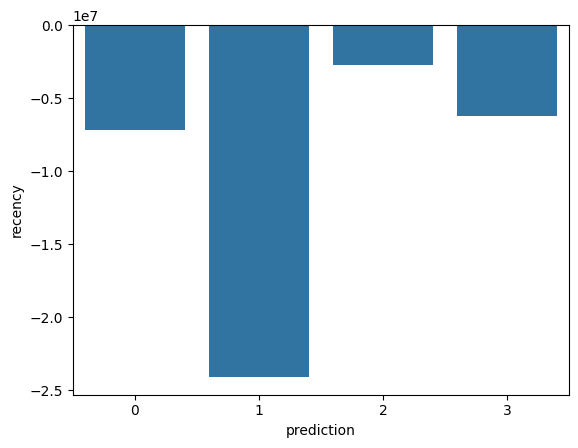

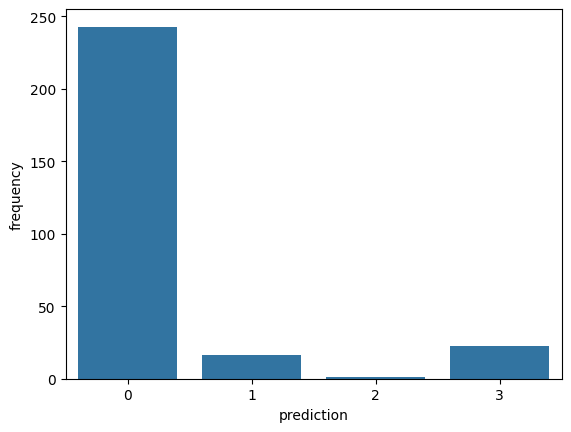

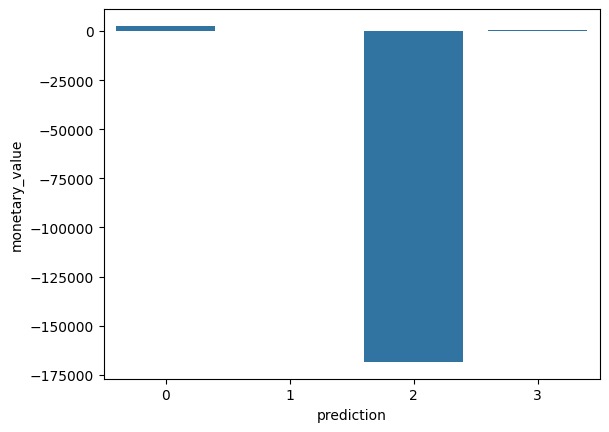

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = preds.select('recency','frequency','monetary_value','prediction')
df_viz = df_viz.toPandas()
avg_df = df_viz.groupby(['prediction'], as_index=False).mean()

list1 = ['recency','frequency','monetary_value']

for i in list1:
    sns.barplot(x='prediction',y=str(i),data=avg_df)
    plt.show()

Here is an overview of characteristics displayed by customers in each cluster:

**Cluster 0**: Customers in this segment display low recency, frequency, and monetary value. They rarely shop on the platform and are low potential customers who are likely to stop doing business with the ecommerce company.

**Cluster 1**: Users in this cluster display high recency but haven’t been seen spending much on the platform. They also don’t visit the site often. This indicates that they might be newer customers who have just started doing business with the company.

**Cluster 2**: Customers in this segment display medium recency and frequency and spend a lot of money on the platform. This indicates that they tend to buy high-value items or make bulk purchases.

**Cluster 3**: The final segment comprises users who display high recency and make frequent purchases on the platform. However, they don’t spend much on the platform, which might mean that they tend to select cheaper items in each purchase.
